# Inference Timing Analysis for Q1 Paper
## Resource-Aware PCG with Meta-RL: Sokoban Level Generation

This notebook analyzes inference timing logs from the CUDA-trained PPO model for Sokoban level generation.

**Model:** `sokoban_PPO_CUDA_20260220_140931`  
**Dataset:** 20 generated levels with comprehensive timing metrics  
**Purpose:** Publication-quality figures and statistical analysis for Q1 academic paper

## 1. Setup and Data Loading

In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set publication-quality plot style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

# Create output directory for figures
import os
os.makedirs('paper_figures/inference', exist_ok=True)

print("✓ Libraries imported and configuration set for publication-quality figures")

✓ Libraries imported and configuration set for publication-quality figures


In [8]:
# Load inference timing data
df = pd.read_csv("inference_timing_sokoban_PPO_CUDA_20260220_140931.csv")

# Display basic information
print(f"Dataset Shape: {df.shape}")
print(f"Number of levels: {len(df)}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Dataset Shape: (20, 31)
Number of levels: 20

Column Names:
['level_id', 'timestamp', 'game', 'algorithm', 'reset_time_ms', 'generation_time_ms', 'extract_time_ms', 'validation_time_ms', 'metrics_time_ms', 'solvability_time_ms', 'save_time_ms', 'total_time_ms', 'steps', 'mean_inference_ms', 'std_inference_ms', 'min_inference_ms', 'max_inference_ms', 'total_reward', 'diversity', 'complexity', 'unique_tiles', 'is_solvable', 'ram_start_pct', 'ram_end_pct', 'ram_delta_pct', 'cpu_start_pct', 'cpu_end_pct', 'cpu_delta_pct', 'gpu_start_pct', 'gpu_end_pct', 'gpu_delta_pct']

First few rows:


,level_id,timestamp,game,algorithm,reset_time_ms,generation_time_ms,extract_time_ms,validation_time_ms,metrics_time_ms,solvability_time_ms,...,is_solvable,ram_start_pct,ram_end_pct,ram_delta_pct,cpu_start_pct,cpu_end_pct,cpu_delta_pct,gpu_start_pct,gpu_end_pct,gpu_delta_pct
0,1,2026-02-20T16:14:30.188565,sokoban,PPO,0.9568,1216.6420,0.0854,0.0612,0.2915,0.0006,...,NaN,52.9,54.5,1.6,6.6,8.9,2.3,10.077715,10.604048,0.526333
1,2,2026-02-20T16:14:31.494209,sokoban,PPO,0.5334,1193.0354,0.0762,0.0526,0.0630,0.0008,...,NaN,54.6,54.5,-0.1,6.2,10.6,4.4,10.647535,10.530901,-0.116634
2,3,2026-02-20T16:14:33.025822,sokoban,PPO,0.4929,1415.8032,0.0968,0.0660,0.0744,0.0007,...,NaN,54.5,54.6,0.1,10.4,10.3,-0.1,10.620165,10.601091,-0.019073
3,4,2026-02-20T16:14:33.800634,sokoban,PPO,0.6088,653.5960,0.3389,0.2684,0.4719,0.0026,...,NaN,55.0,55.0,0.0,12.3,1.5,-10.8,10.594988,10.572100,-0.022888
4,5,2026-02-20T16:14:34.792724,sokoban,PPO,1.0992,874.2456,0.1453,0.1095,0.1686,0.0013,...,NaN,55.0,54.8,-0.2,5.3,2.5,-2.8,10.569048,10.541582,-0.027466


## 2. Summary Statistics for Paper

In [9]:
# Calculate key statistics for paper
timing_cols = ['total_time_ms', 'generation_time_ms', 'mean_inference_ms', 
               'validation_time_ms', 'solvability_time_ms']
quality_cols = ['steps', 'total_reward', 'diversity', 'complexity']
resource_cols = ['ram_delta_pct', 'cpu_delta_pct', 'gpu_delta_pct']

print("="*80)
print("TIMING PERFORMANCE (for Table 1 in paper)")
print("="*80)
for col in timing_cols:
    if col in df.columns:
        mean_val = df[col].mean()
        std_val = df[col].std()
        print(f"{col:30s}: {mean_val:8.2f} ± {std_val:6.2f} ms")

print("\n" + "="*80)
print("GENERATION QUALITY METRICS (for Table 2 in paper)")
print("="*80)
for col in quality_cols:
    if col in df.columns:
        mean_val = df[col].mean()
        std_val = df[col].std()
        print(f"{col:30s}: {mean_val:8.2f} ± {std_val:6.2f}")

print("\n" + "="*80)
print("RESOURCE EFFICIENCY (for Table 3 in paper)")
print("="*80)
for col in resource_cols:
    if col in df.columns:
        mean_val = df[col].mean()
        std_val = df[col].std()
        print(f"{col:30s}: {mean_val:8.2f} ± {std_val:6.2f} %")

TIMING PERFORMANCE (for Table 1 in paper)
total_time_ms                 :  1597.10 ± 576.87 ms
generation_time_ms            :  1586.26 ± 578.58 ms
mean_inference_ms             :     3.19 ±   2.85 ms
validation_time_ms            :     0.09 ±   0.06 ms
solvability_time_ms           :     0.00 ±   0.00 ms

GENERATION QUALITY METRICS (for Table 2 in paper)
steps                         :    13.45 ±   5.29
total_reward                  :     8.25 ±   8.25
diversity                     :     0.15 ±   0.04
complexity                    :     0.97 ±   0.06

RESOURCE EFFICIENCY (for Table 3 in paper)
ram_delta_pct                 :     0.06 ±   0.41 %
cpu_delta_pct                 :    -0.29 ±   6.69 %
gpu_delta_pct                 :     0.00 ±   0.18 %


## 3. Figure 1: Timing Breakdown Visualization

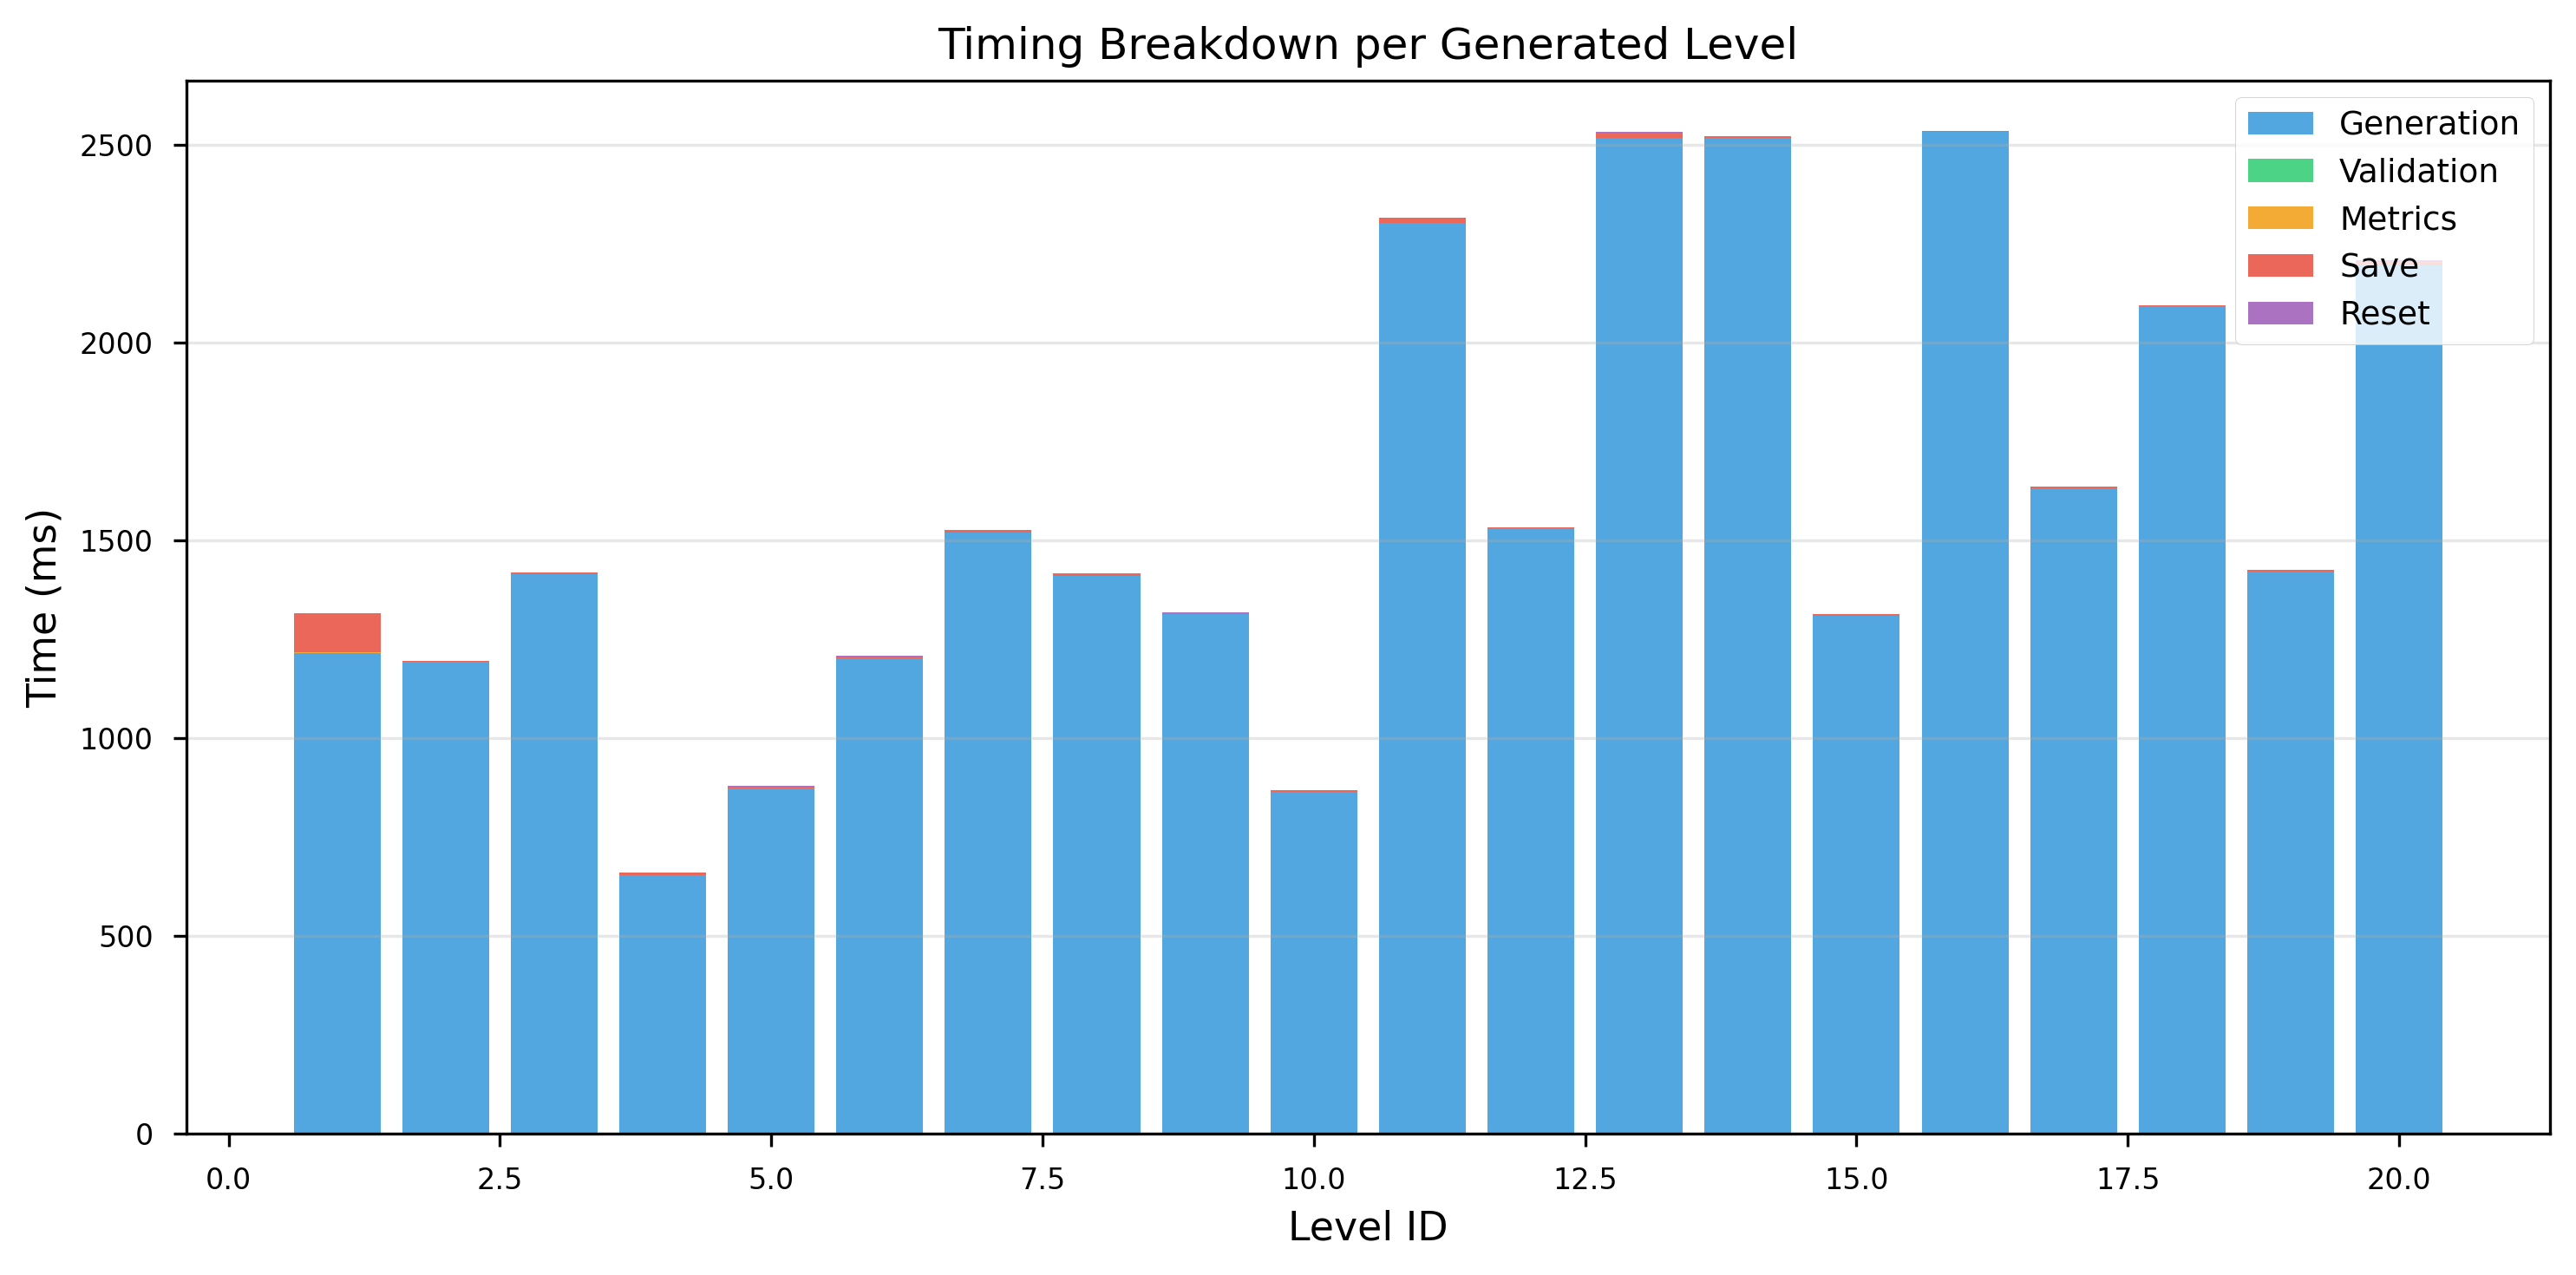

✓ Figure 1 saved: paper_figures/inference/fig1_timing_breakdown.png


In [10]:
# Stacked bar chart showing timing breakdown
fig, ax = plt.subplots(figsize=(10, 5))

# Calculate percentage contribution of each timing component
timing_components = {
    'Generation': df['generation_time_ms'].values,
    'Validation': df['validation_time_ms'].values,
    'Metrics': df['metrics_time_ms'].values,
    'Save': df['save_time_ms'].values,
    'Reset': df['reset_time_ms'].values
}

# Stack the bars
bottom = np.zeros(len(df))
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
for (label, values), color in zip(timing_components.items(), colors):
    ax.bar(df['level_id'], values, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += values

ax.set_xlabel('Level ID')
ax.set_ylabel('Time (ms)')
ax.set_title('Timing Breakdown per Generated Level')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('paper_figures/inference/fig1_timing_breakdown.png', bbox_inches='tight')
plt.show()

print("✓ Figure 1 saved: paper_figures/inference/fig1_timing_breakdown.png")

## 4. Figure 2: Inference Performance Distribution

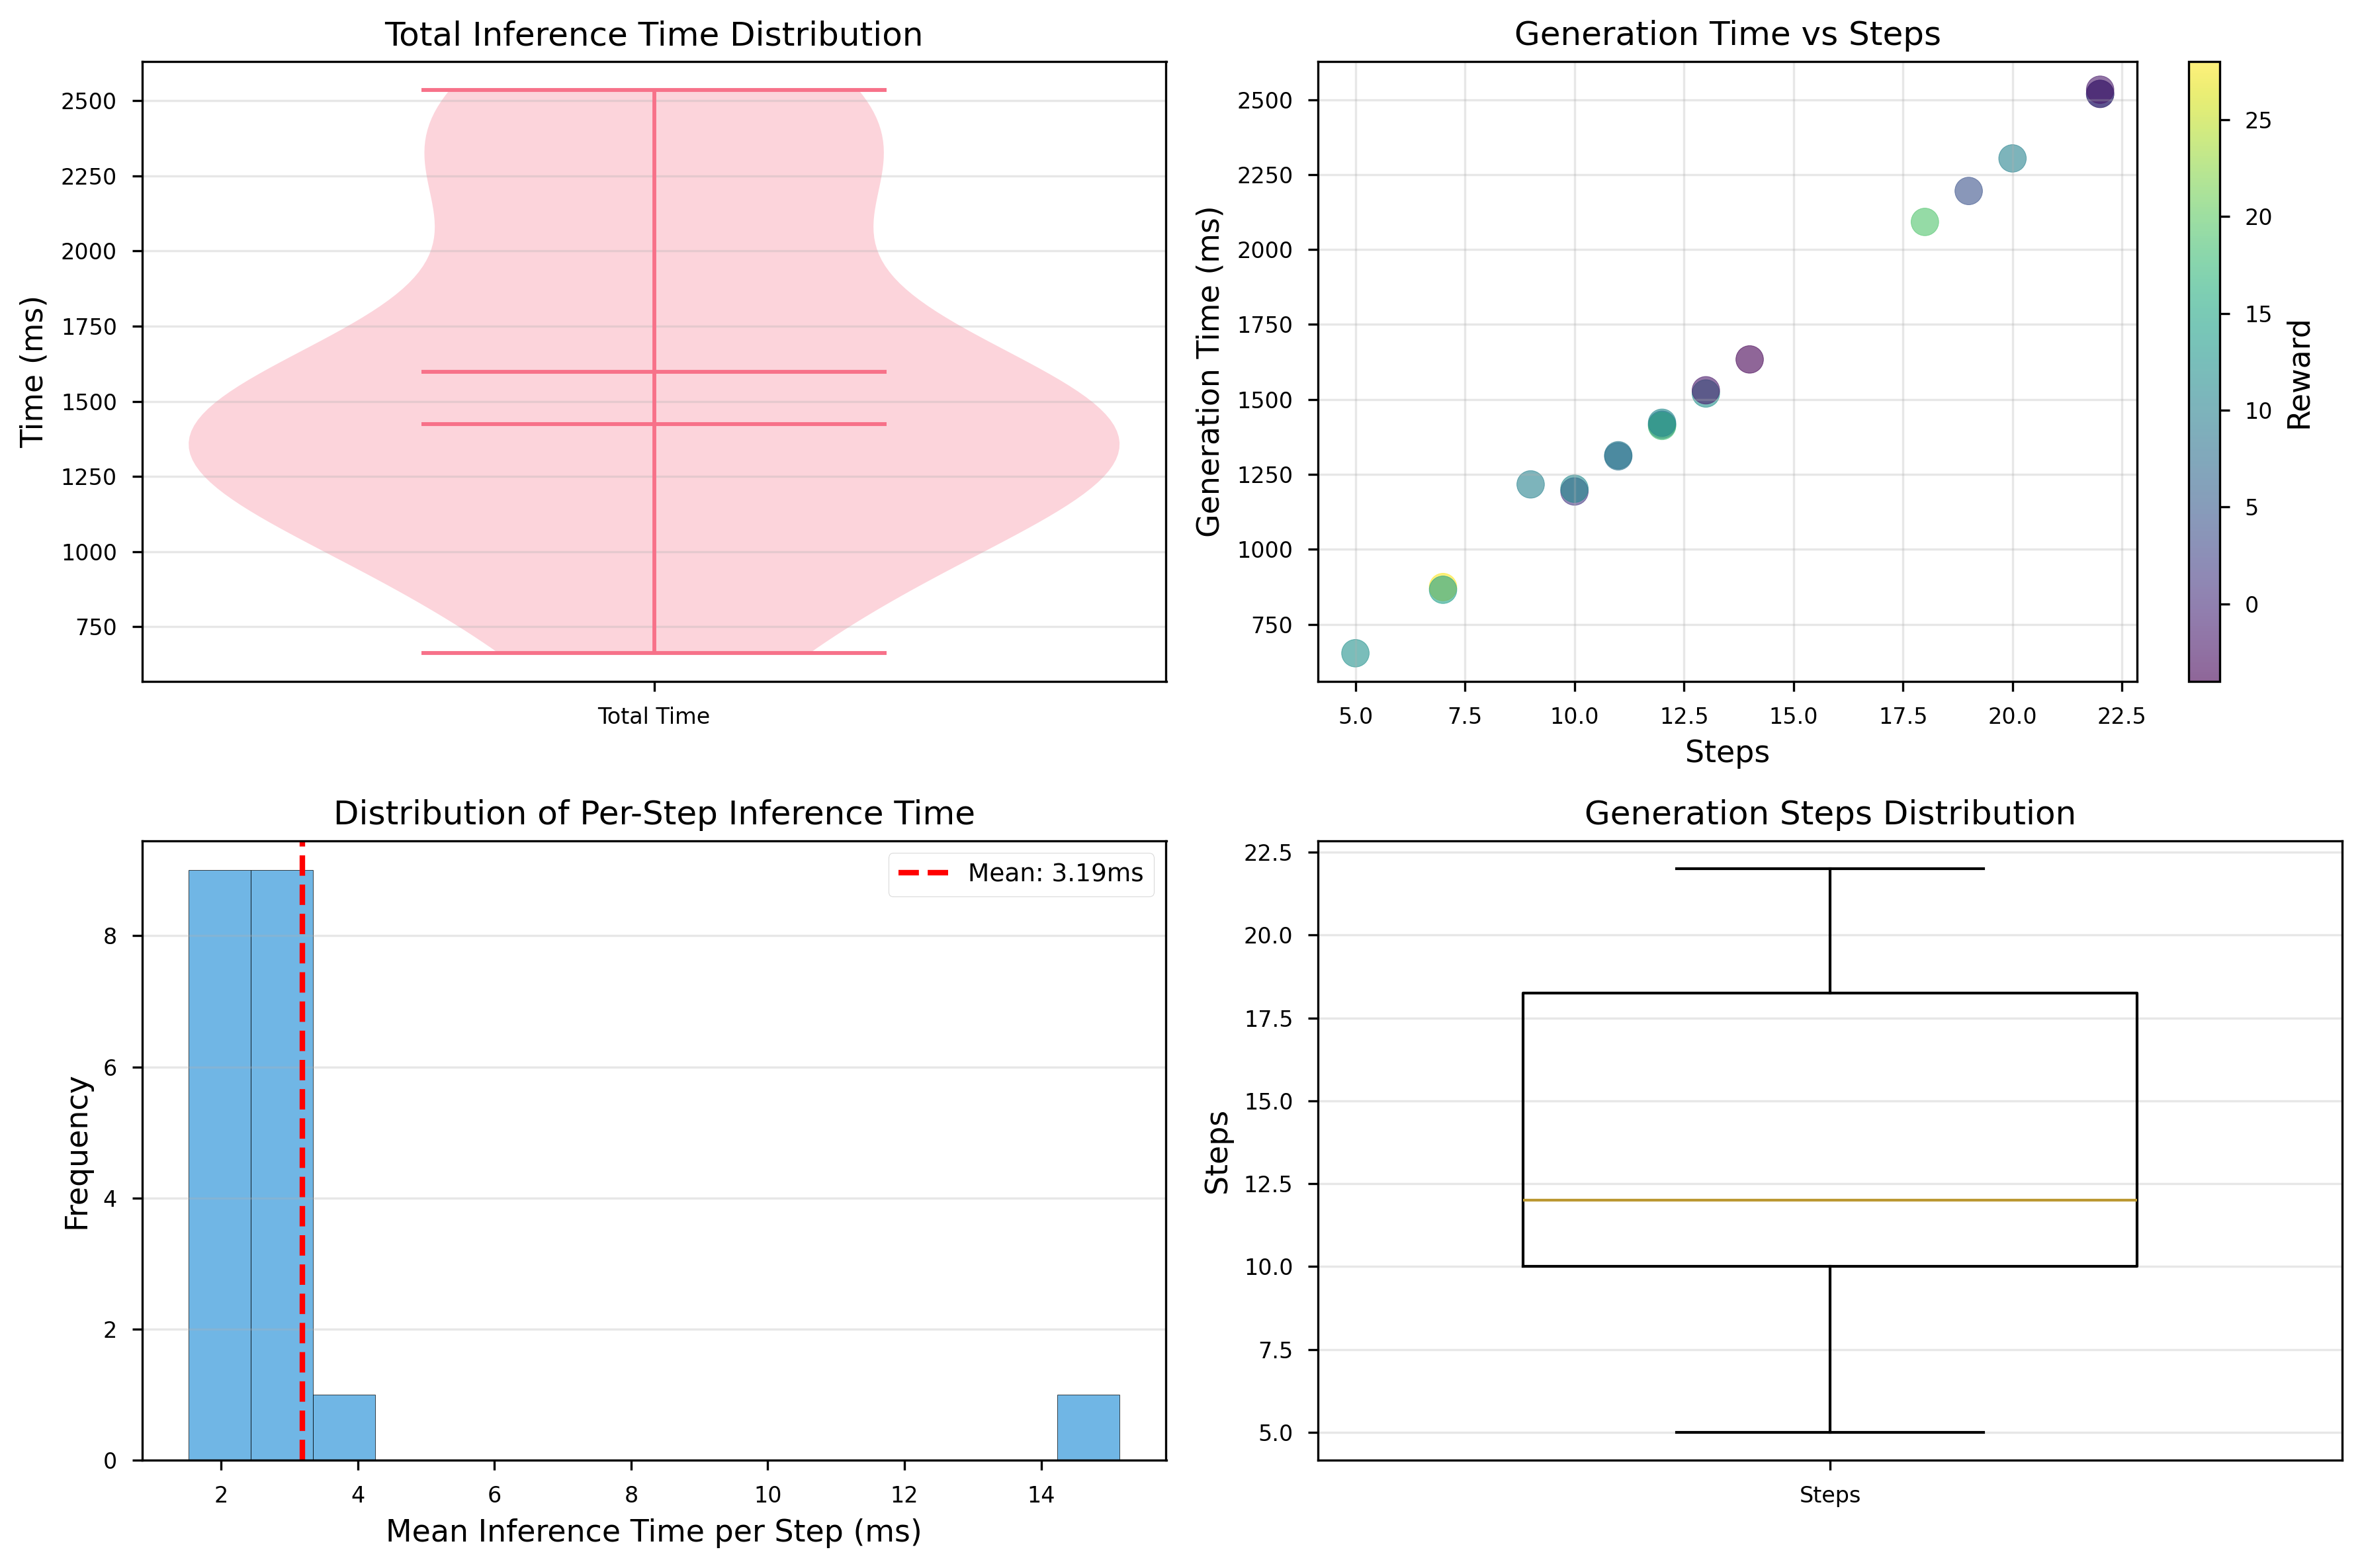

✓ Figure 2 saved: paper_figures/inference/fig2_performance_distribution.png


In [11]:
# Box plots and violin plots for timing distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Total time distribution
axes[0, 0].violinplot([df['total_time_ms']], positions=[1], widths=0.7, 
                       showmeans=True, showmedians=True)
axes[0, 0].set_ylabel('Time (ms)')
axes[0, 0].set_title('Total Inference Time Distribution')
axes[0, 0].set_xticks([1])
axes[0, 0].set_xticklabels(['Total Time'])
axes[0, 0].grid(axis='y', alpha=0.3)

# Generation time vs steps
axes[0, 1].scatter(df['steps'], df['generation_time_ms'], alpha=0.6, s=100, c=df['total_reward'], cmap='viridis')
axes[0, 1].set_xlabel('Steps')
axes[0, 1].set_ylabel('Generation Time (ms)')
axes[0, 1].set_title('Generation Time vs Steps')
axes[0, 1].grid(alpha=0.3)
cbar = plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])
cbar.set_label('Reward')

# Inference time per step
axes[1, 0].hist(df['mean_inference_ms'], bins=15, alpha=0.7, color='#3498db', edgecolor='black')
axes[1, 0].set_xlabel('Mean Inference Time per Step (ms)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Per-Step Inference Time')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].axvline(df['mean_inference_ms'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["mean_inference_ms"].mean():.2f}ms')
axes[1, 0].legend()

# Steps distribution
axes[1, 1].boxplot([df['steps']], widths=0.6)
axes[1, 1].set_ylabel('Steps')
axes[1, 1].set_title('Generation Steps Distribution')
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels(['Steps'])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('paper_figures/inference/fig2_performance_distribution.png', bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved: paper_figures/inference/fig2_performance_distribution.png")

## 5. Figure 3: Resource Utilization Analysis

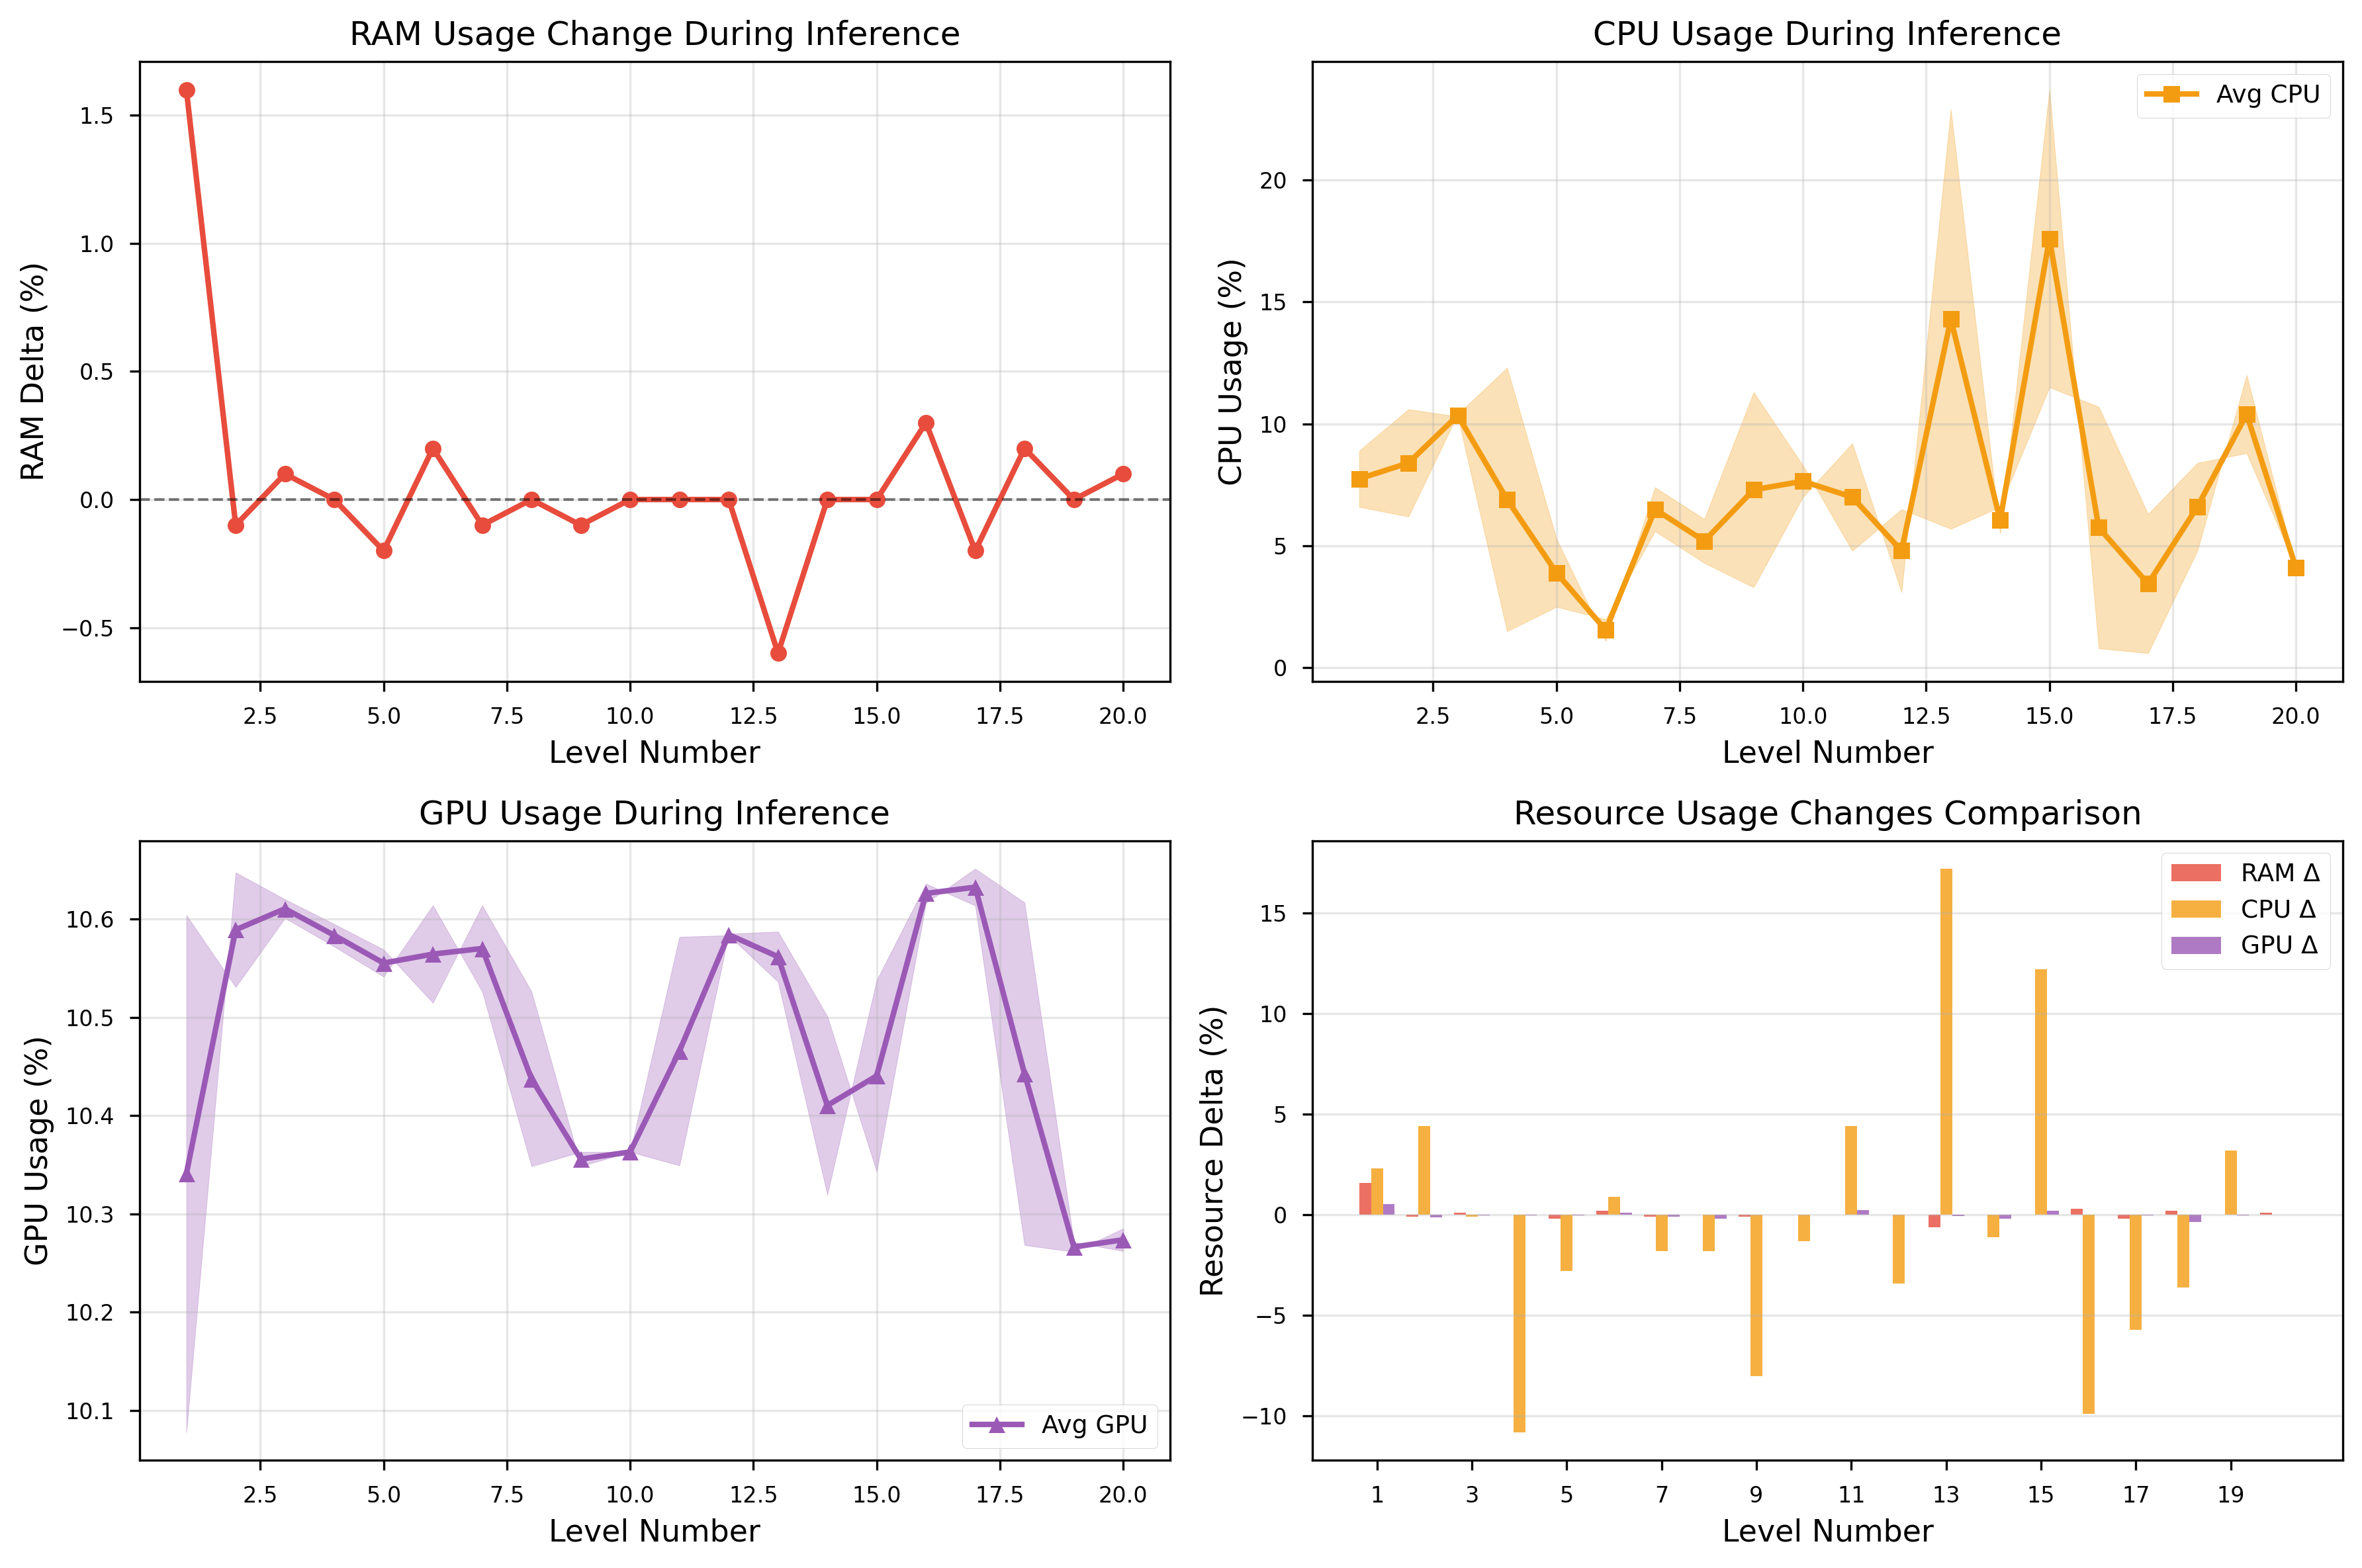

✓ Figure 3 saved: paper_figures/inference/fig3_resource_utilization.png


In [12]:
# Resource usage during inference
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# RAM usage over levels
level_nums = range(1, len(df) + 1)
axes[0, 0].plot(level_nums, df['ram_delta_pct'], marker='o', linestyle='-', color='#e74c3c', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Level Number')
axes[0, 0].set_ylabel('RAM Delta (%)')
axes[0, 0].set_title('RAM Usage Change During Inference')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# CPU usage over levels
axes[0, 1].fill_between(level_nums, df['cpu_start_pct'], df['cpu_end_pct'], alpha=0.3, color='#f39c12')
axes[0, 1].plot(level_nums, (df['cpu_start_pct'] + df['cpu_end_pct']) / 2, marker='s', color='#f39c12', linewidth=2, markersize=6, label='Avg CPU')
axes[0, 1].set_xlabel('Level Number')
axes[0, 1].set_ylabel('CPU Usage (%)')
axes[0, 1].set_title('CPU Usage During Inference')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# GPU usage over levels
axes[1, 0].fill_between(level_nums, df['gpu_start_pct'], df['gpu_end_pct'], alpha=0.3, color='#9b59b6')
axes[1, 0].plot(level_nums, (df['gpu_start_pct'] + df['gpu_end_pct']) / 2, marker='^', color='#9b59b6', linewidth=2, markersize=6, label='Avg GPU')
axes[1, 0].set_xlabel('Level Number')
axes[1, 0].set_ylabel('GPU Usage (%)')
axes[1, 0].set_title('GPU Usage During Inference')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Combined resource usage
width = 0.25
x = np.arange(len(df))
axes[1, 1].bar(x - width, df['ram_delta_pct'], width, label='RAM Δ', alpha=0.8, color='#e74c3c')
axes[1, 1].bar(x, df['cpu_delta_pct'], width, label='CPU Δ', alpha=0.8, color='#f39c12')
axes[1, 1].bar(x + width, df['gpu_delta_pct'], width, label='GPU Δ', alpha=0.8, color='#9b59b6')
axes[1, 1].set_xlabel('Level Number')
axes[1, 1].set_ylabel('Resource Delta (%)')
axes[1, 1].set_title('Resource Usage Changes Comparison')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_xticks(x[::2])
axes[1, 1].set_xticklabels([str(i+1) for i in x[::2]])

plt.tight_layout()
plt.savefig('paper_figures/inference/fig3_resource_utilization.png', bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: paper_figures/inference/fig3_resource_utilization.png")

## 6. Figure 4: Quality Metrics Analysis

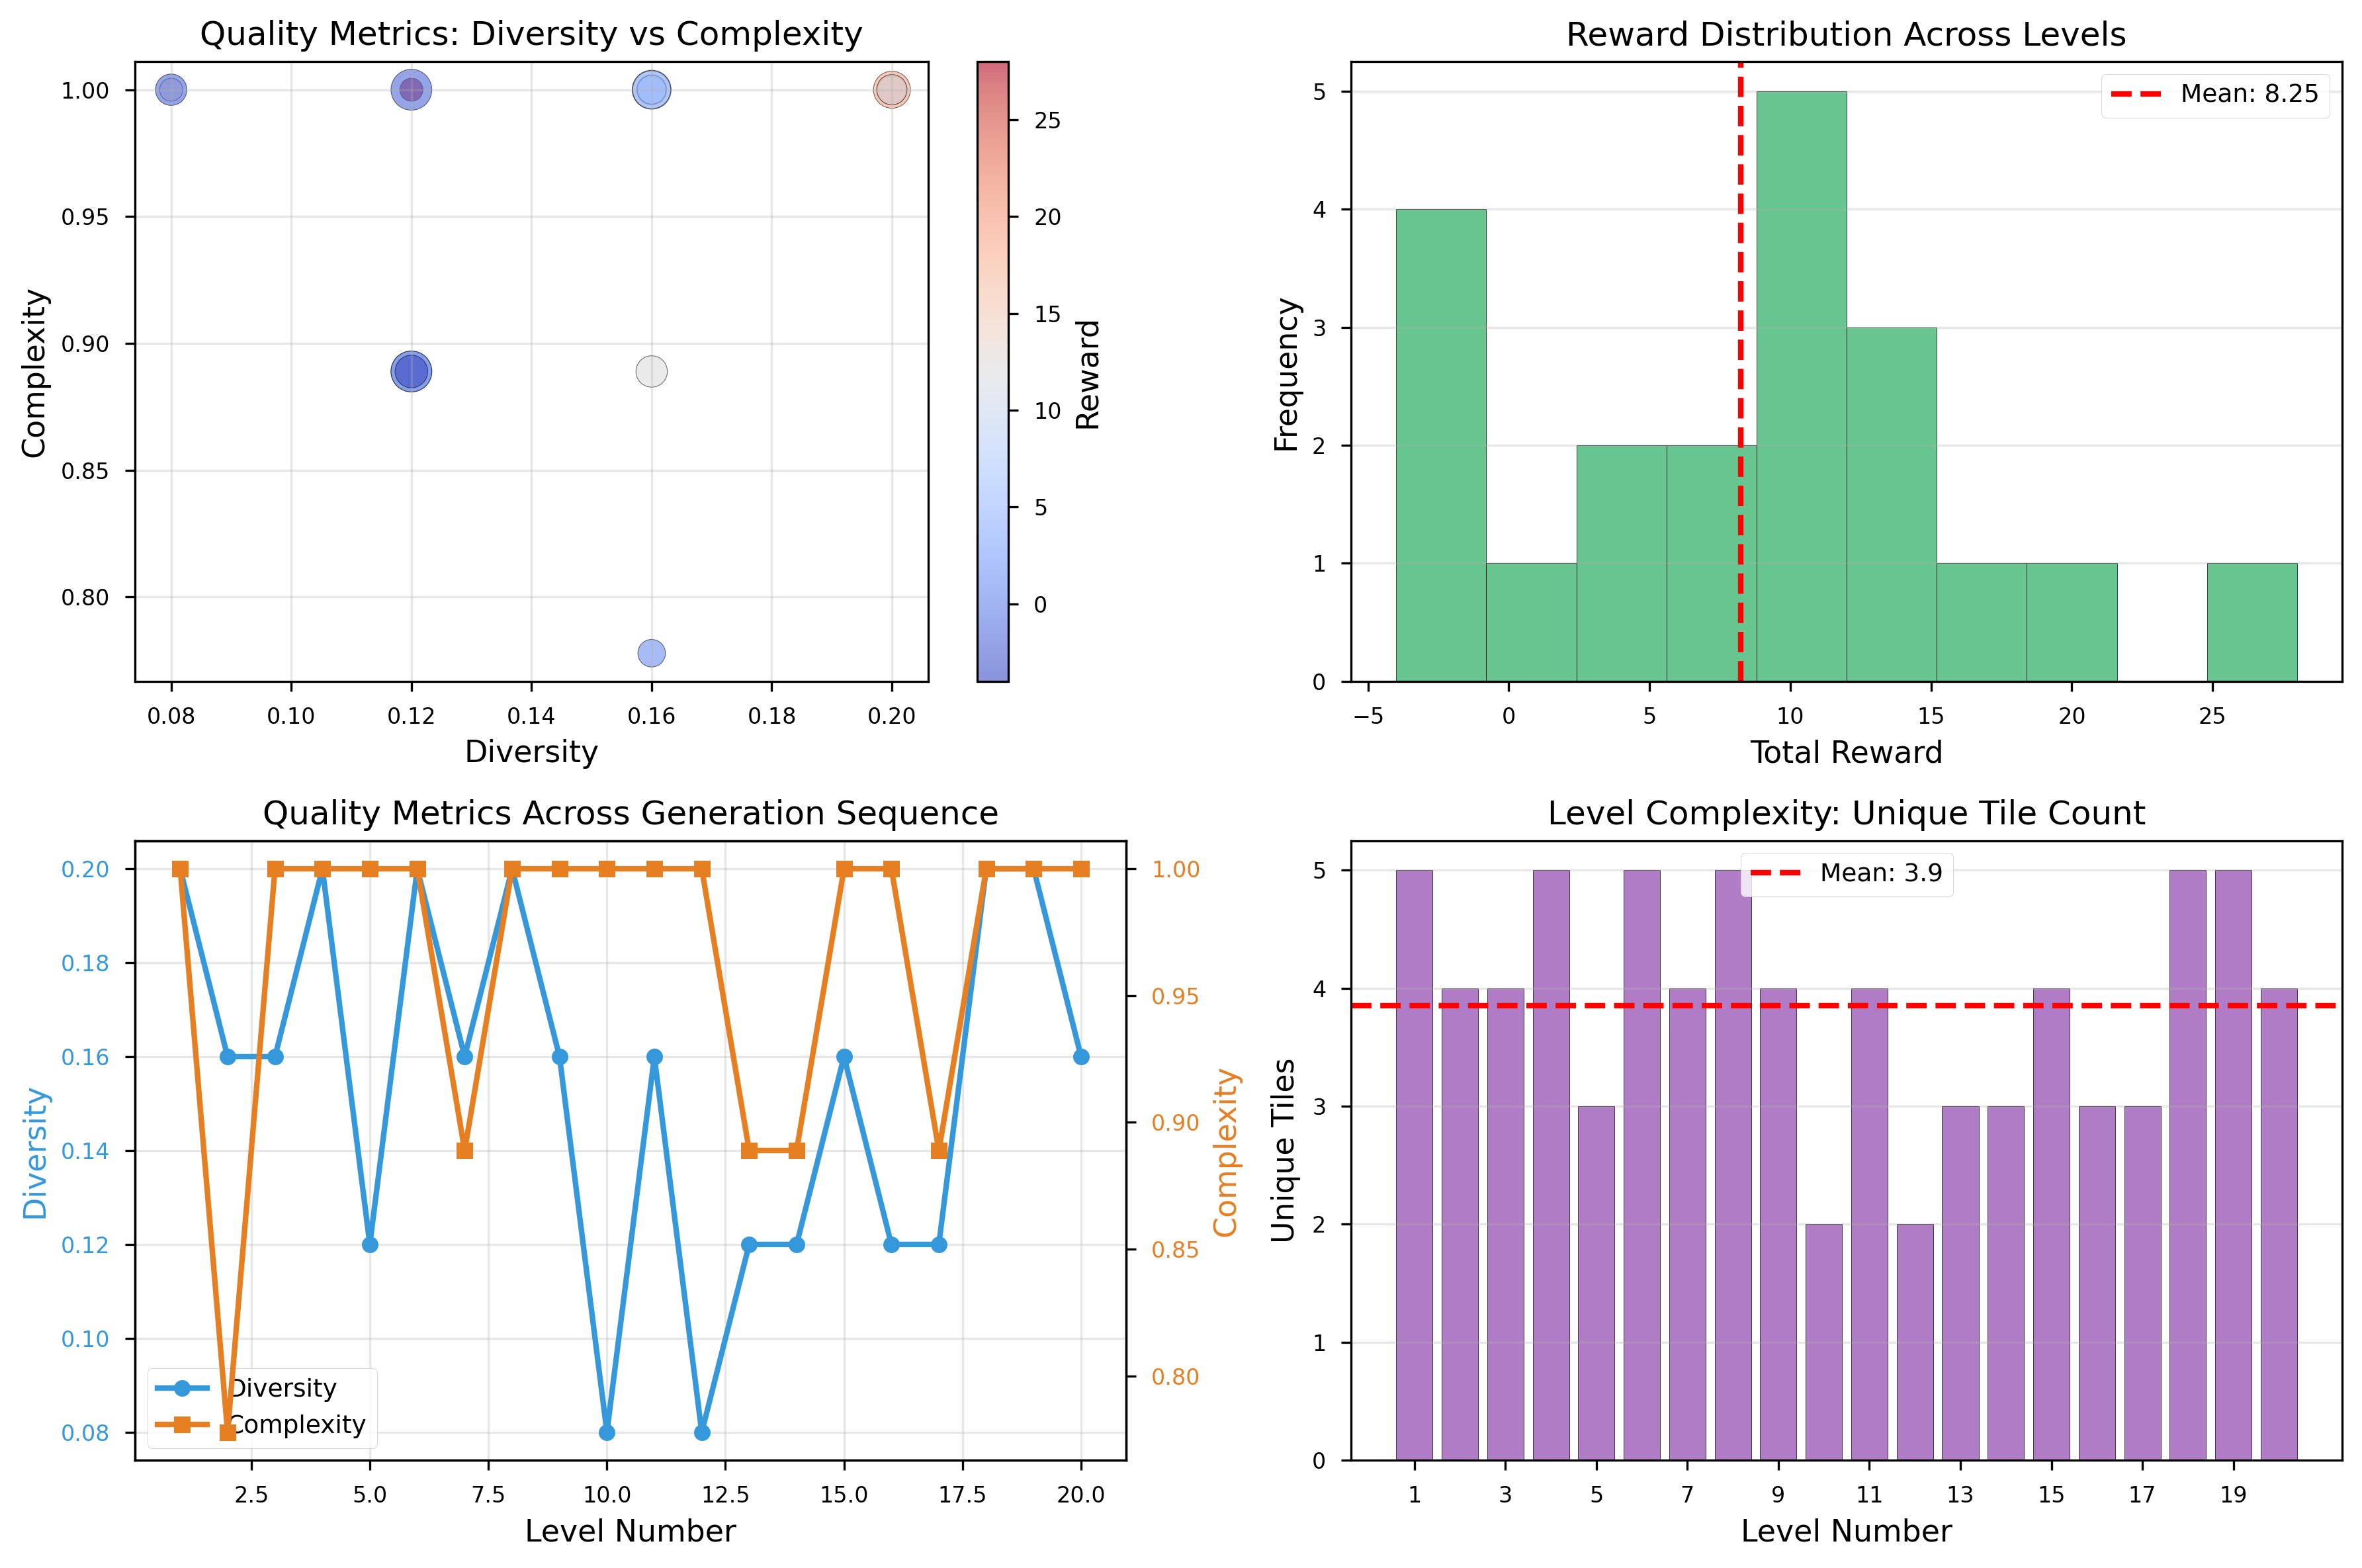

✓ Figure 4 saved: paper_figures/inference/fig4_quality_metrics.png


In [13]:
# Quality metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Diversity vs Complexity scatter
scatter = axes[0, 0].scatter(df['diversity'], df['complexity'], s=df['steps']*10, 
                             c=df['total_reward'], cmap='coolwarm', alpha=0.6, edgecolors='black')
axes[0, 0].set_xlabel('Diversity')
axes[0, 0].set_ylabel('Complexity')
axes[0, 0].set_title('Quality Metrics: Diversity vs Complexity')
axes[0, 0].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0, 0])
cbar.set_label('Reward')

# Reward distribution
axes[0, 1].hist(df['total_reward'], bins=10, alpha=0.7, color='#27ae60', edgecolor='black')
axes[0, 1].set_xlabel('Total Reward')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Reward Distribution Across Levels')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].axvline(df['total_reward'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["total_reward"].mean():.2f}')
axes[0, 1].legend()

# Quality metrics over level sequence
level_nums = range(1, len(df) + 1)
ax2_1 = axes[1, 0]
ax2_1_twin = ax2_1.twinx()
ax2_1.plot(level_nums, df['diversity'], marker='o', color='#3498db', linewidth=2, markersize=6, label='Diversity')
ax2_1_twin.plot(level_nums, df['complexity'], marker='s', color='#e67e22', linewidth=2, markersize=6, label='Complexity')
ax2_1.set_xlabel('Level Number')
ax2_1.set_ylabel('Diversity', color='#3498db')
ax2_1_twin.set_ylabel('Complexity', color='#e67e22')
ax2_1.set_title('Quality Metrics Across Generation Sequence')
ax2_1.tick_params(axis='y', labelcolor='#3498db')
ax2_1_twin.tick_params(axis='y', labelcolor='#e67e22')
ax2_1.grid(alpha=0.3)
lines1, labels1 = ax2_1.get_legend_handles_labels()
lines2, labels2 = ax2_1_twin.get_legend_handles_labels()
ax2_1.legend(lines1 + lines2, labels1 + labels2, loc='best')

# Unique tiles distribution
axes[1, 1].bar(range(len(df)), df['unique_tiles'], alpha=0.7, color='#8e44ad', edgecolor='black')
axes[1, 1].set_xlabel('Level Number')
axes[1, 1].set_ylabel('Unique Tiles')
axes[1, 1].set_title('Level Complexity: Unique Tile Count')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axhline(df['unique_tiles'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["unique_tiles"].mean():.1f}')
axes[1, 1].legend()
axes[1, 1].set_xticks(range(0, len(df), 2))
axes[1, 1].set_xticklabels(range(1, len(df)+1, 2))

plt.tight_layout()
plt.savefig('paper_figures/inference/fig4_quality_metrics.png', bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: paper_figures/inference/fig4_quality_metrics.png")

## 7. Figure 5: Correlation Heatmap (Timing vs Quality vs Resources)

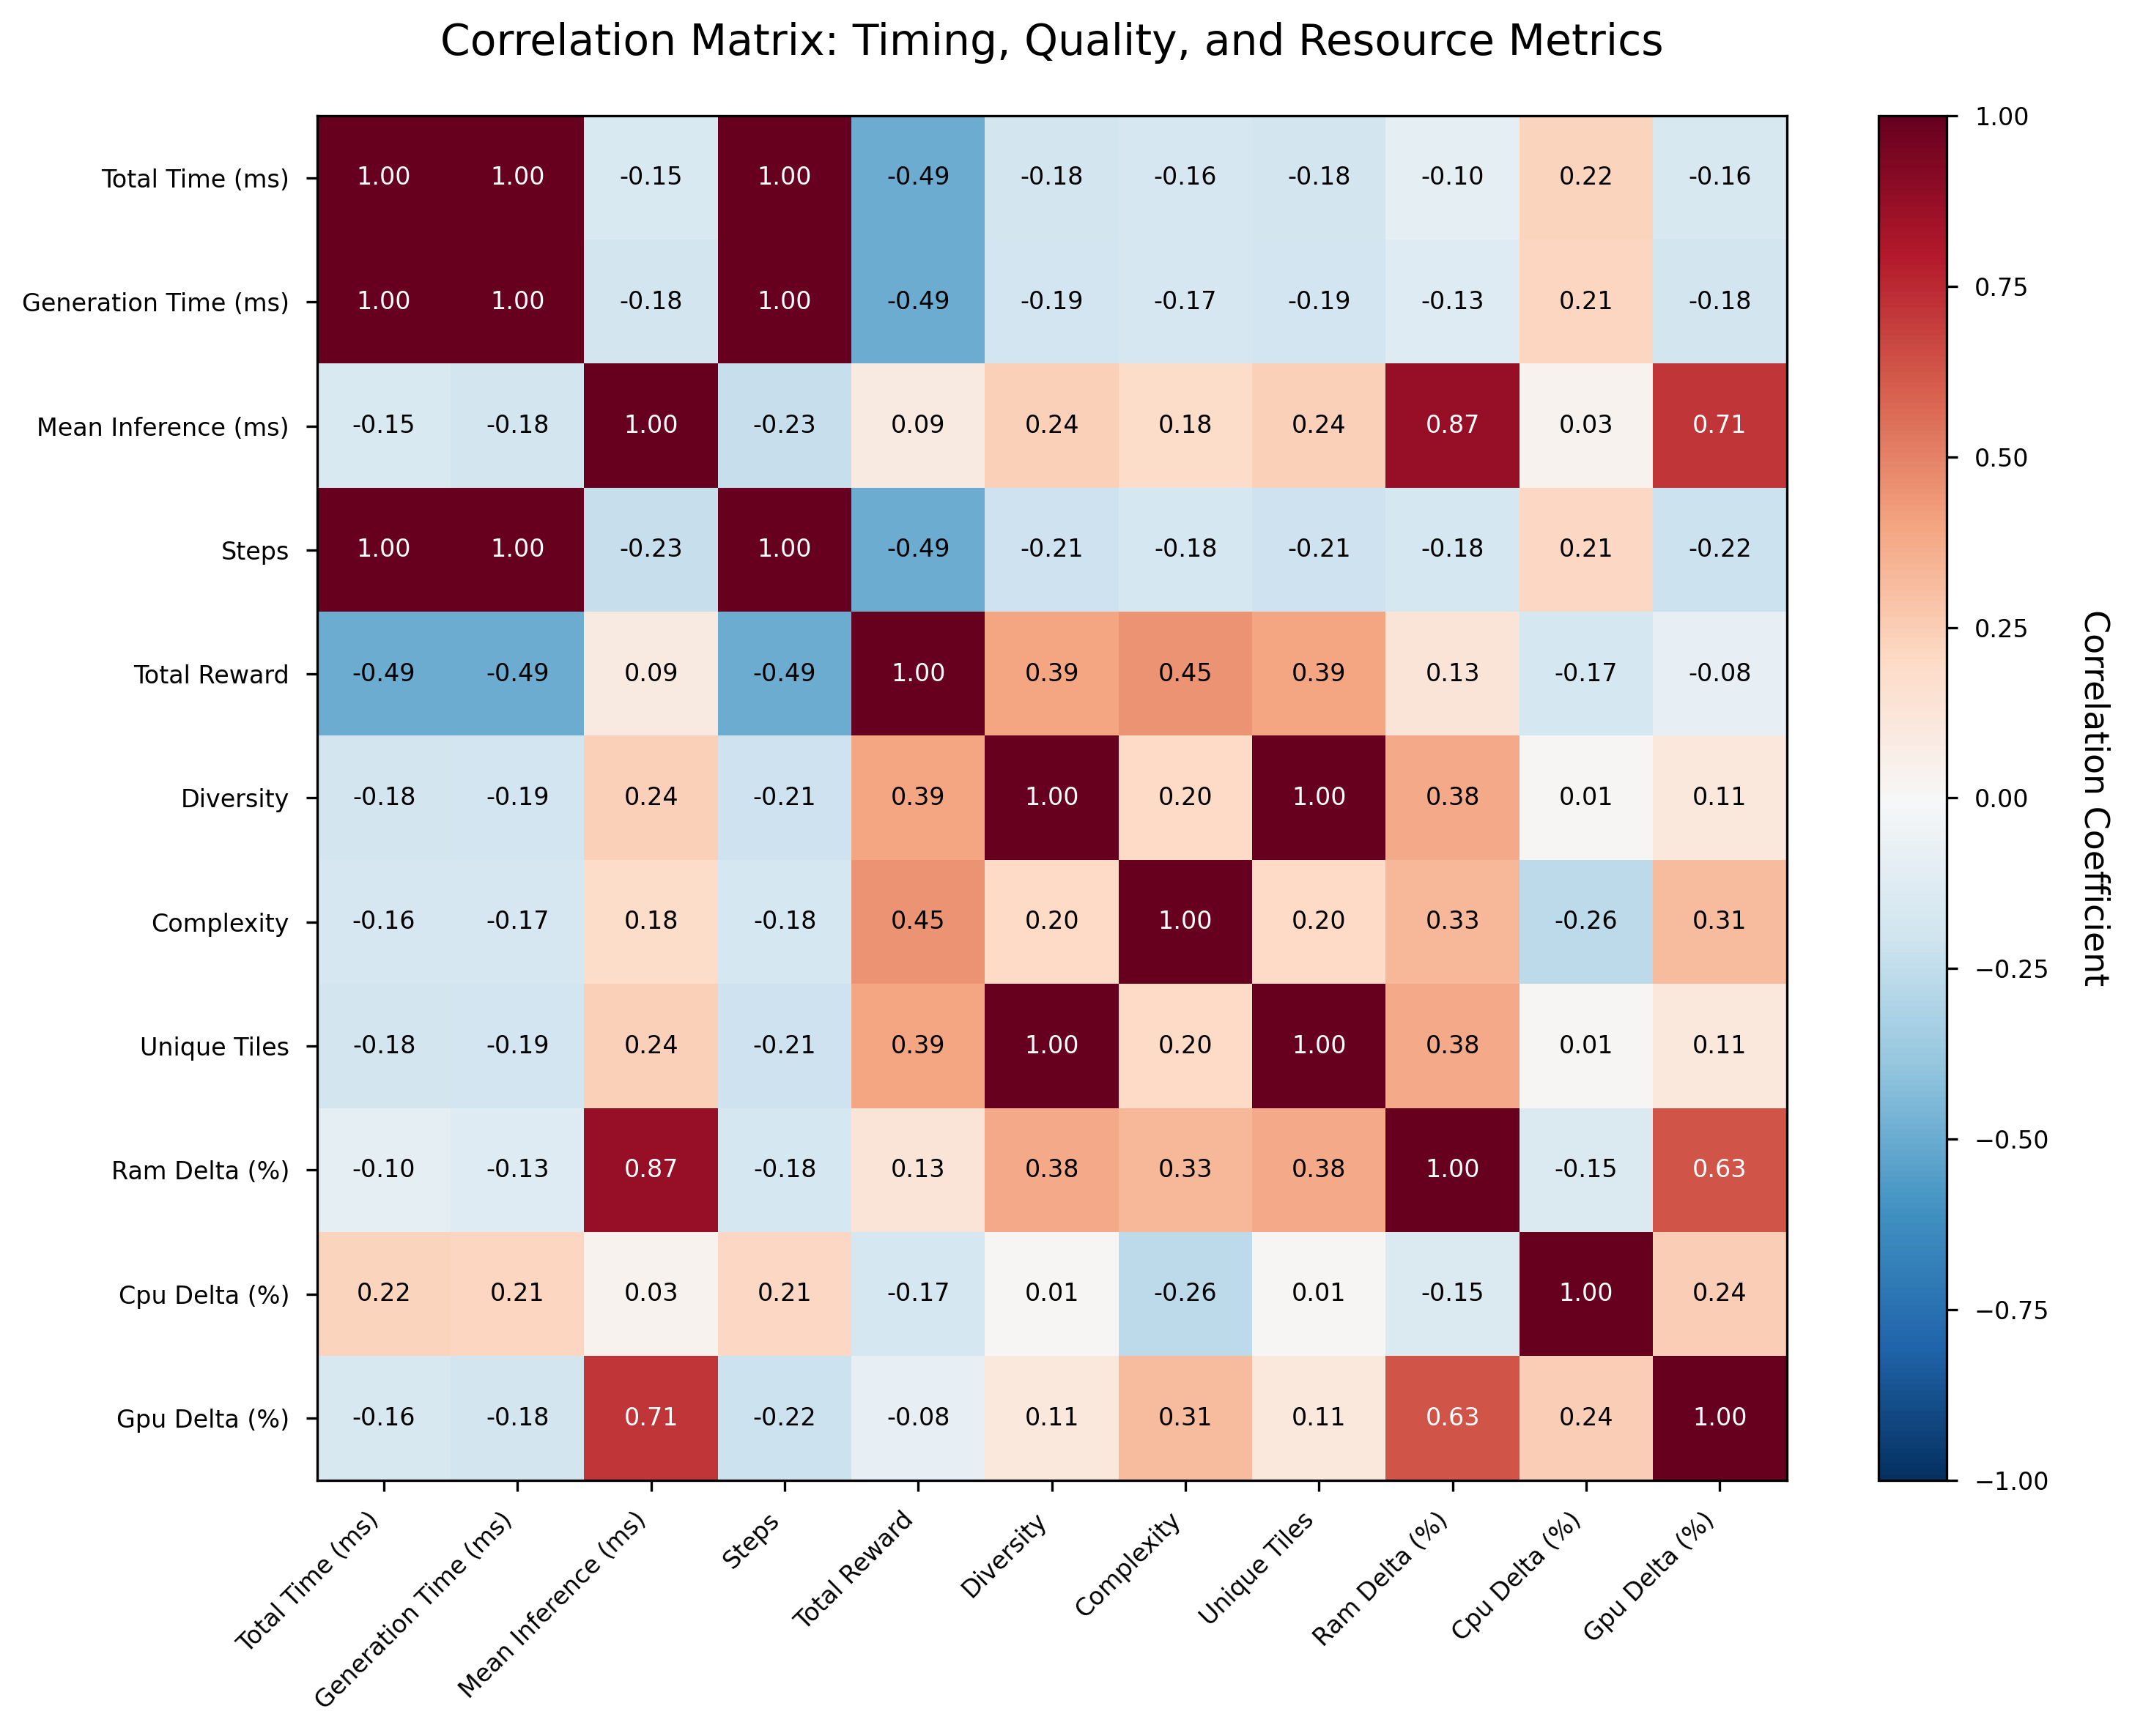


=== Significant Correlations (|r| > 0.5) ===
diversity ↔ unique_tiles: r = 1.000
total_time_ms ↔ generation_time_ms: r = 0.999
generation_time_ms ↔ steps: r = 0.999
total_time_ms ↔ steps: r = 0.996
mean_inference_ms ↔ ram_delta_pct: r = 0.874
mean_inference_ms ↔ gpu_delta_pct: r = 0.715
ram_delta_pct ↔ gpu_delta_pct: r = 0.629

✓ Figure 5 saved: paper_figures/inference/fig5_correlation_heatmap.png


In [14]:
# Correlation analysis
correlation_cols = [
    'total_time_ms', 'generation_time_ms', 'mean_inference_ms', 
    'steps', 'total_reward', 'diversity', 'complexity', 'unique_tiles',
    'ram_delta_pct', 'cpu_delta_pct', 'gpu_delta_pct'
]

corr_matrix = df[correlation_cols].corr()

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)

# Set ticks and labels
ax.set_xticks(np.arange(len(correlation_cols)))
ax.set_yticks(np.arange(len(correlation_cols)))
ax.set_xticklabels([col.replace('_', ' ').title().replace('Ms', '(ms)').replace('Pct', '(%)') for col in correlation_cols], rotation=45, ha='right')
ax.set_yticklabels([col.replace('_', ' ').title().replace('Ms', '(ms)').replace('Pct', '(%)') for col in correlation_cols])

# Add correlation values to cells
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha='center', va='center', color='black' if abs(corr_matrix.iloc[i, j]) < 0.5 else 'white',
                      fontsize=8)

ax.set_title('Correlation Matrix: Timing, Quality, and Resource Metrics', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('paper_figures/inference/fig5_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print significant correlations
print("\n=== Significant Correlations (|r| > 0.5) ===")
significant_corrs = []
for i in range(len(correlation_cols)):
    for j in range(i+1, len(correlation_cols)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            significant_corrs.append((correlation_cols[i], correlation_cols[j], corr_val))

significant_corrs.sort(key=lambda x: abs(x[2]), reverse=True)
for var1, var2, corr in significant_corrs:
    print(f"{var1} ↔ {var2}: r = {corr:.3f}")

print("\n✓ Figure 5 saved: paper_figures/inference/fig5_correlation_heatmap.png")

## 8. Figure 6: Comprehensive Dashboard

d:\Work\thesis\RAPCG-MetaRL\pcg_env\lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
d:\Work\thesis\RAPCG-MetaRL\pcg_env\lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


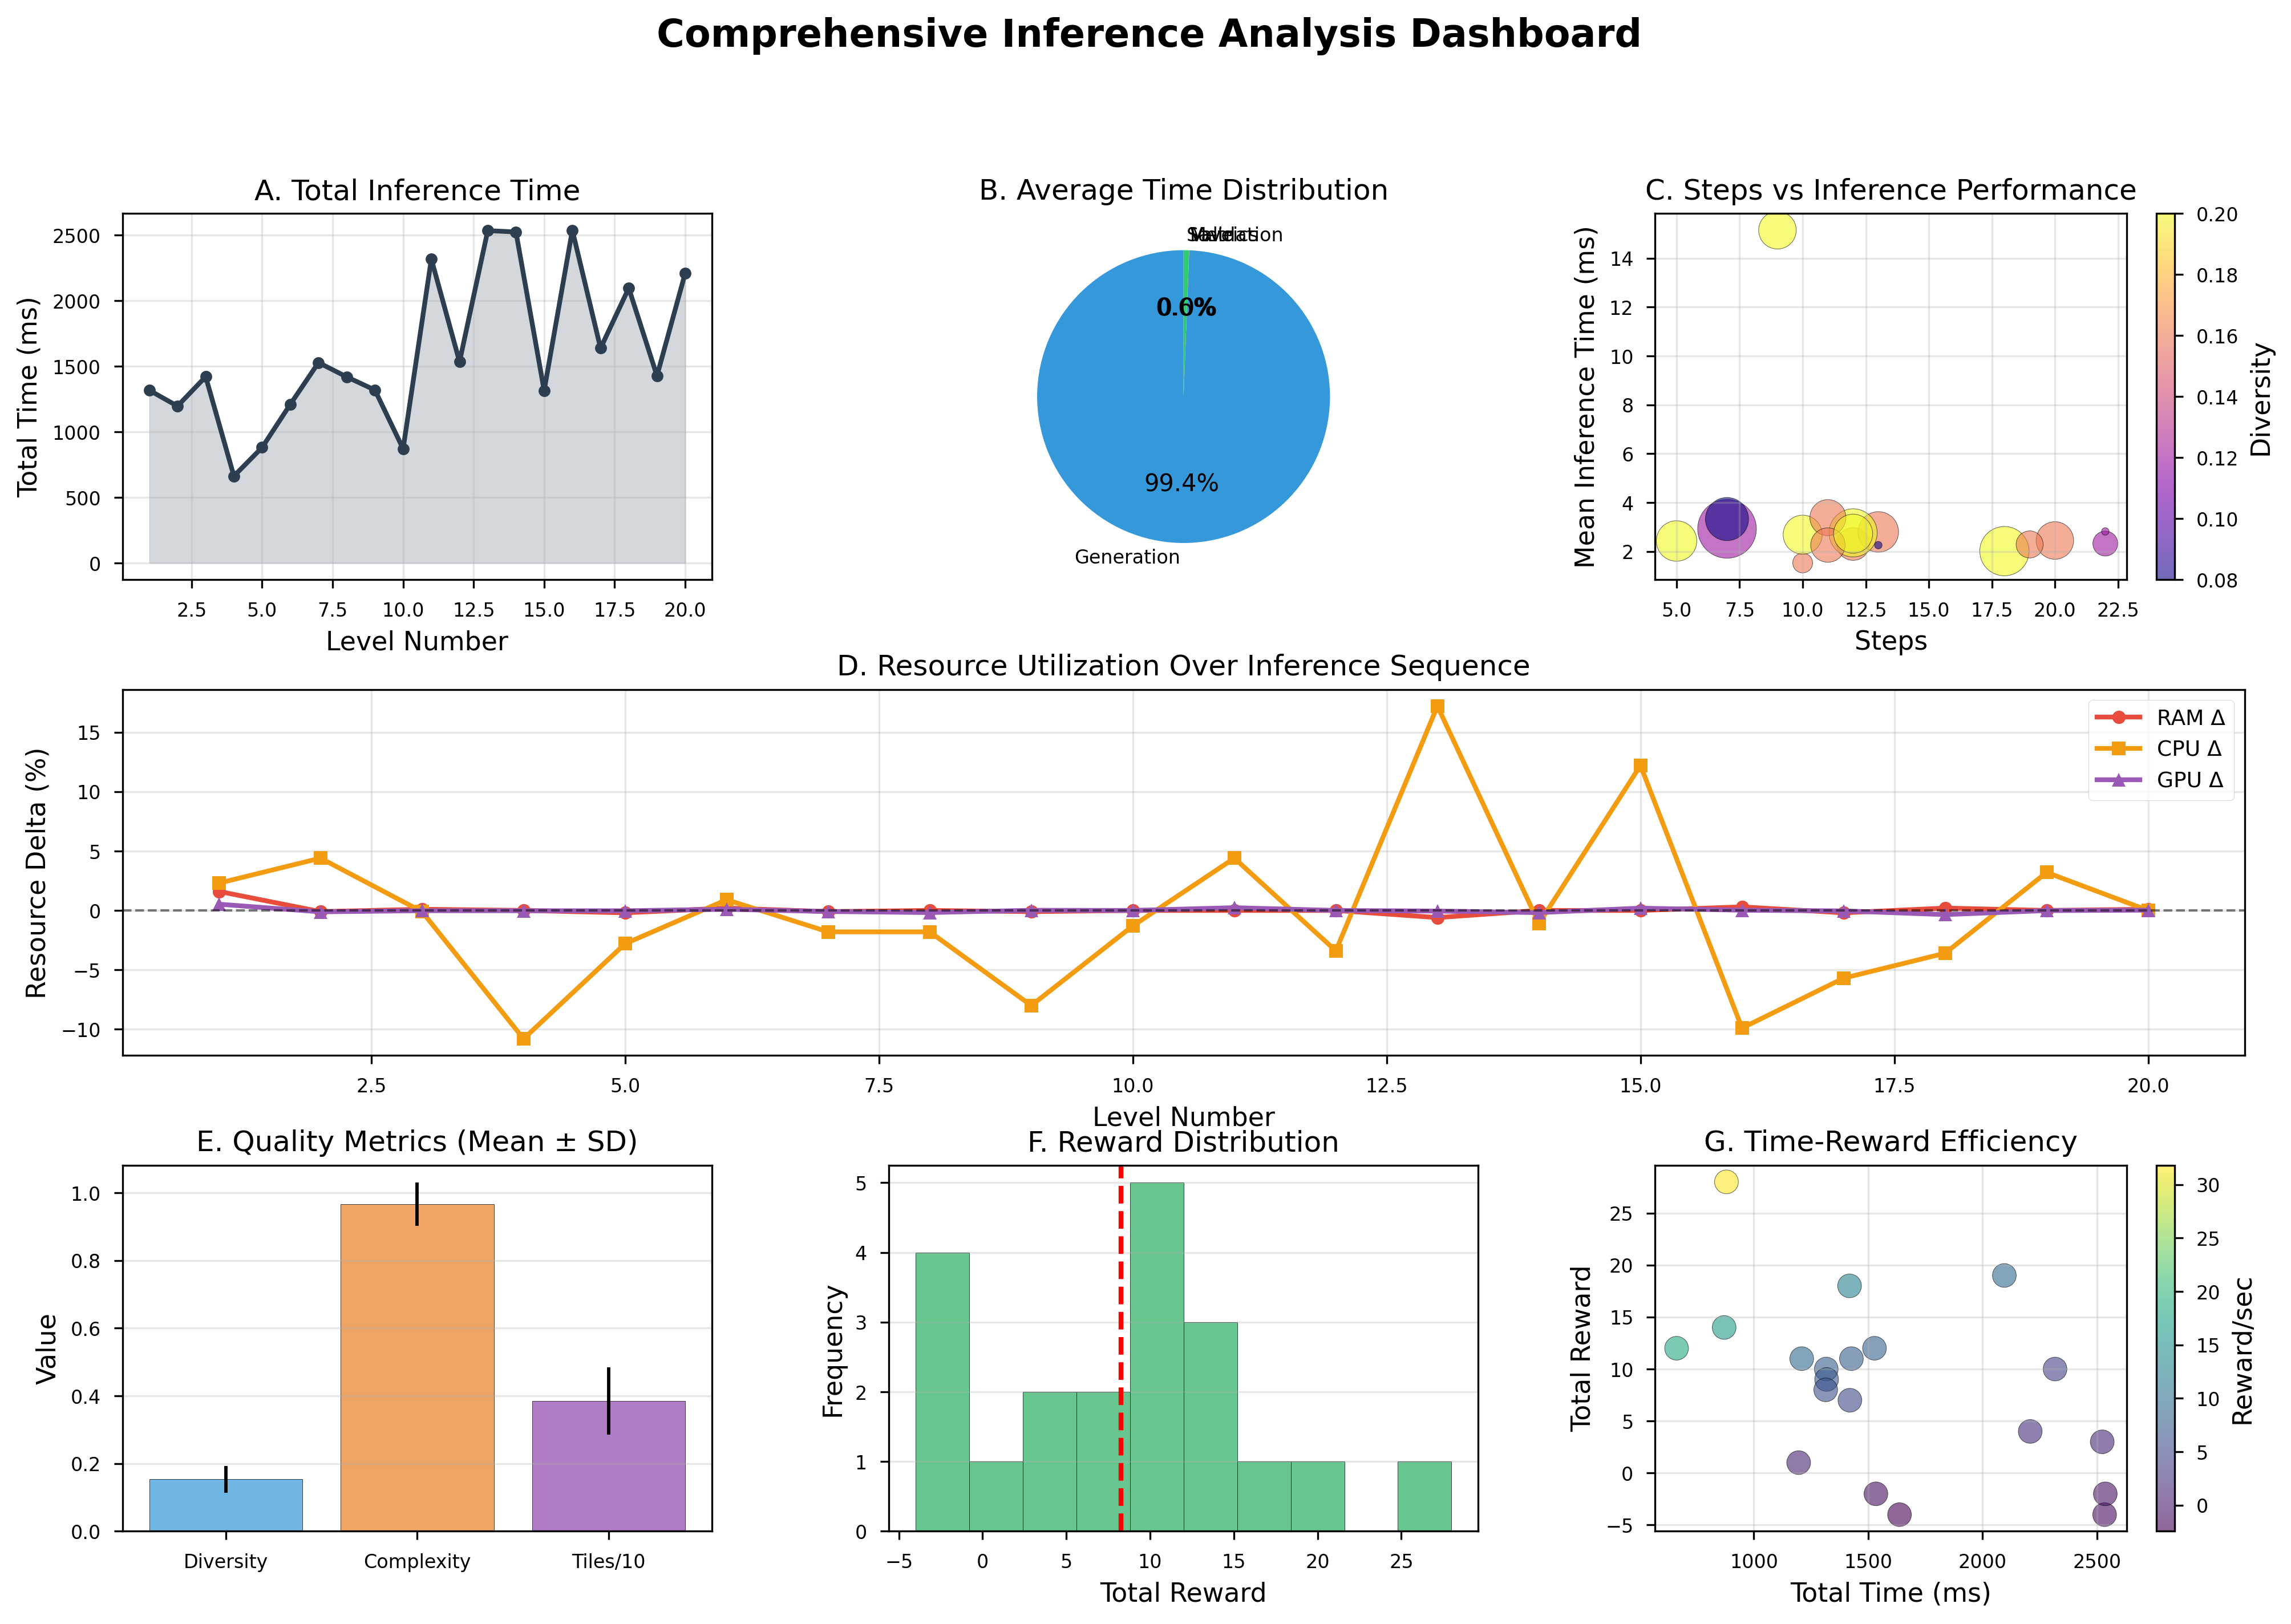

✓ Figure 6 saved: paper_figures/inference/fig6_comprehensive_dashboard.png


In [15]:
# Comprehensive multi-panel dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

level_nums = range(1, len(df) + 1)

# Panel 1: Total time over levels
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(level_nums, df['total_time_ms'], marker='o', linewidth=2, markersize=5, color='#2c3e50')
ax1.fill_between(level_nums, df['total_time_ms'], alpha=0.2, color='#2c3e50')
ax1.set_xlabel('Level Number')
ax1.set_ylabel('Total Time (ms)')
ax1.set_title('A. Total Inference Time')
ax1.grid(alpha=0.3)

# Panel 2: Inference breakdown
ax2 = fig.add_subplot(gs[0, 1])
timing_components = df[['generation_time_ms', 'validation_time_ms', 'metrics_time_ms', 'save_time_ms']].mean()
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
ax2.pie(timing_components, labels=['Generation', 'Validation', 'Metrics', 'Save'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('B. Average Time Distribution')

# Panel 3: Steps vs Performance
ax3 = fig.add_subplot(gs[0, 2])
scatter = ax3.scatter(df['steps'], df['mean_inference_ms'], s=df['total_reward']*20+50, 
                     c=df['diversity'], cmap='plasma', alpha=0.6, edgecolors='black')
ax3.set_xlabel('Steps')
ax3.set_ylabel('Mean Inference Time (ms)')
ax3.set_title('C. Steps vs Inference Performance')
ax3.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Diversity')

# Panel 4: Resource usage trends
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(level_nums, df['ram_delta_pct'], marker='o', label='RAM Δ', linewidth=2, color='#e74c3c')
ax4.plot(level_nums, df['cpu_delta_pct'], marker='s', label='CPU Δ', linewidth=2, color='#f39c12')
ax4.plot(level_nums, df['gpu_delta_pct'], marker='^', label='GPU Δ', linewidth=2, color='#9b59b6')
ax4.set_xlabel('Level Number')
ax4.set_ylabel('Resource Delta (%)')
ax4.set_title('D. Resource Utilization Over Inference Sequence')
ax4.legend(loc='best')
ax4.grid(alpha=0.3)
ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Panel 5: Quality metrics
ax5 = fig.add_subplot(gs[2, 0])
quality_means = [df['diversity'].mean(), df['complexity'].mean(), df['unique_tiles'].mean()/10]
quality_stds = [df['diversity'].std(), df['complexity'].std(), df['unique_tiles'].std()/10]
x_pos = np.arange(len(['Diversity', 'Complexity', 'Tiles/10']))
ax5.bar(x_pos, quality_means, yerr=quality_stds, alpha=0.7, color=['#3498db', '#e67e22', '#8e44ad'], 
        edgecolor='black', capsize=5)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(['Diversity', 'Complexity', 'Tiles/10'])
ax5.set_ylabel('Value')
ax5.set_title('E. Quality Metrics (Mean ± SD)')
ax5.grid(axis='y', alpha=0.3)

# Panel 6: Reward distribution
ax6 = fig.add_subplot(gs[2, 1])
ax6.hist(df['total_reward'], bins=10, alpha=0.7, color='#27ae60', edgecolor='black')
ax6.set_xlabel('Total Reward')
ax6.set_ylabel('Frequency')
ax6.set_title('F. Reward Distribution')
ax6.grid(axis='y', alpha=0.3)
ax6.axvline(df['total_reward'].mean(), color='red', linestyle='--', linewidth=2)

# Panel 7: Efficiency scatter
ax7 = fig.add_subplot(gs[2, 2])
efficiency = df['total_reward'] / (df['total_time_ms'] / 1000)  # reward per second
ax7.scatter(df['total_time_ms'], df['total_reward'], s=100, c=efficiency, cmap='viridis', 
           alpha=0.6, edgecolors='black')
ax7.set_xlabel('Total Time (ms)')
ax7.set_ylabel('Total Reward')
ax7.set_title('G. Time-Reward Efficiency')
ax7.grid(alpha=0.3)
cbar = plt.colorbar(ax7.collections[0], ax=ax7)
cbar.set_label('Reward/sec')

plt.suptitle('Comprehensive Inference Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('paper_figures/inference/fig6_comprehensive_dashboard.png', bbox_inches='tight')
plt.show()

print("✓ Figure 6 saved: paper_figures/inference/fig6_comprehensive_dashboard.png")

## 9. Statistical Summary for Paper Tables

In [16]:
# Generate LaTeX-ready tables for paper
from scipy import stats

print("="*60)
print("LATEX TABLE 1: INFERENCE TIMING PERFORMANCE")
print("="*60)

timing_data = {
    'Metric': ['Total Time', 'Generation Time', 'Mean Inference/Step', 'Validation Time', 'Metrics Calculation', 'Save Time'],
    'Mean (ms)': [
        df['total_time_ms'].mean(),
        df['generation_time_ms'].mean(),
        df['mean_inference_ms'].mean(),
        df['validation_time_ms'].mean(),
        df['metrics_time_ms'].mean(),
        df['save_time_ms'].mean()
    ],
    'Std (ms)': [
        df['total_time_ms'].std(),
        df['generation_time_ms'].std(),
        df['mean_inference_ms'].std(),
        df['validation_time_ms'].std(),
        df['metrics_time_ms'].std(),
        df['save_time_ms'].std()
    ],
    'Min (ms)': [
        df['total_time_ms'].min(),
        df['generation_time_ms'].min(),
        df['min_inference_ms'].min(),
        df['validation_time_ms'].min(),
        df['metrics_time_ms'].min(),
        df['save_time_ms'].min()
    ],
    'Max (ms)': [
        df['total_time_ms'].max(),
        df['generation_time_ms'].max(),
        df['max_inference_ms'].max(),
        df['validation_time_ms'].max(),
        df['metrics_time_ms'].max(),
        df['save_time_ms'].max()
    ]
}

timing_df = pd.DataFrame(timing_data)
print(timing_df.to_string(index=False))
print("\nLaTeX Format:")
print(timing_df.to_latex(index=False, float_format="%.2f"))

print("\n" + "="*60)
print("LATEX TABLE 2: QUALITY METRICS")
print("="*60)

quality_data = {
    'Metric': ['Steps', 'Total Reward', 'Diversity', 'Complexity', 'Unique Tiles'],
    'Mean': [
        df['steps'].mean(),
        df['total_reward'].mean(),
        df['diversity'].mean(),
        df['complexity'].mean(),
        df['unique_tiles'].mean()
    ],
    'Std': [
        df['steps'].std(),
        df['total_reward'].std(),
        df['diversity'].std(),
        df['complexity'].std(),
        df['unique_tiles'].std()
    ],
    'Min': [
        df['steps'].min(),
        df['total_reward'].min(),
        df['diversity'].min(),
        df['complexity'].min(),
        df['unique_tiles'].min()
    ],
    'Max': [
        df['steps'].max(),
        df['total_reward'].max(),
        df['diversity'].max(),
        df['complexity'].max(),
        df['unique_tiles'].max()
    ],
    'Median': [
        df['steps'].median(),
        df['total_reward'].median(),
        df['diversity'].median(),
        df['complexity'].median(),
        df['unique_tiles'].median()
    ]
}

quality_df = pd.DataFrame(quality_data)
print(quality_df.to_string(index=False))
print("\nLaTeX Format:")
print(quality_df.to_latex(index=False, float_format="%.3f"))

print("\n" + "="*60)
print("LATEX TABLE 3: RESOURCE UTILIZATION")
print("="*60)

resource_data = {
    'Resource': ['RAM Delta (%)', 'CPU Average (%)', 'GPU Average (%)'],
    'Mean': [
        df['ram_delta_pct'].mean(),
        ((df['cpu_start_pct'] + df['cpu_end_pct']) / 2).mean(),
        ((df['gpu_start_pct'] + df['gpu_end_pct']) / 2).mean()
    ],
    'Std': [
        df['ram_delta_pct'].std(),
        ((df['cpu_start_pct'] + df['cpu_end_pct']) / 2).std(),
        ((df['gpu_start_pct'] + df['gpu_end_pct']) / 2).std()
    ],
    'Min': [
        df['ram_delta_pct'].min(),
        df['cpu_start_pct'].min(),
        df['gpu_start_pct'].min()
    ],
    'Max': [
        df['ram_delta_pct'].max(),
        df['cpu_end_pct'].max(),
        df['gpu_end_pct'].max()
    ]
}

resource_df = pd.DataFrame(resource_data)
print(resource_df.to_string(index=False))
print("\nLaTeX Format:")
print(resource_df.to_latex(index=False, float_format="%.2f"))

print("\n" + "="*60)
print("KEY FINDINGS FOR PAPER")
print("="*60)

# Statistical tests
normality_time = stats.shapiro(df['total_time_ms'])
normality_quality = stats.shapiro(df['diversity'])

print(f"\n1. Inference Speed:")
print(f"   - Average generation: {df['generation_time_ms'].mean():.2f} ± {df['generation_time_ms'].std():.2f} ms")
print(f"   - Per-step inference: {df['mean_inference_ms'].mean():.2f} ± {df['mean_inference_ms'].std():.2f} ms")
print(f"   - Throughput: {1000 / df['total_time_ms'].mean():.2f} levels/second")

print(f"\n2. Quality Consistency:")
print(f"   - Diversity coefficient of variation: {(df['diversity'].std() / df['diversity'].mean() * 100):.1f}%")
print(f"   - Complexity coefficient of variation: {(df['complexity'].std() / df['complexity'].mean() * 100):.1f}%")

print(f"\n3. Resource Efficiency:")
print(f"   - Average RAM impact: {df['ram_delta_pct'].mean():.3f}% per level")
print(f"   - Average CPU utilization: {((df['cpu_start_pct'] + df['cpu_end_pct']) / 2).mean():.1f}%")
print(f"   - Average GPU utilization: {((df['gpu_start_pct'] + df['gpu_end_pct']) / 2).mean():.1f}%")

print(f"\n4. Statistical Properties:")
print(f"   - Total time normality (Shapiro-Wilk): W={normality_time.statistic:.4f}, p={normality_time.pvalue:.4f}")
print(f"   - Diversity normality (Shapiro-Wilk): W={normality_quality.statistic:.4f}, p={normality_quality.pvalue:.4f}")

# Efficiency metric
efficiency = df['total_reward'] / (df['total_time_ms'] / 1000)
print(f"\n5. Time-Reward Efficiency:")
print(f"   - Mean: {efficiency.mean():.2f} reward/second")
print(f"   - Std: {efficiency.std():.2f} reward/second")

print("\n" + "="*60)

LATEX TABLE 1: INFERENCE TIMING PERFORMANCE
             Metric   Mean (ms)   Std (ms)  Min (ms)  Max (ms)
         Total Time 1597.104230 576.869405  662.2134 2536.4071
    Generation Time 1586.256190 578.576847  653.5960 2532.9888
Mean Inference/Step    3.190259   2.847707    1.0382  123.2959
    Validation Time    0.092690   0.060426    0.0469    0.2684
Metrics Calculation    0.145630   0.117365    0.0522    0.4719
          Save Time    9.676620  21.172777    2.0498   98.5875

LaTeX Format:
\begin{tabular}{lrrrr}
\toprule
Metric & Mean (ms) & Std (ms) & Min (ms) & Max (ms) \\
\midrule
Total Time & 1597.10 & 576.87 & 662.21 & 2536.41 \\
Generation Time & 1586.26 & 578.58 & 653.60 & 2532.99 \\
Mean Inference/Step & 3.19 & 2.85 & 1.04 & 123.30 \\
Validation Time & 0.09 & 0.06 & 0.05 & 0.27 \\
Metrics Calculation & 0.15 & 0.12 & 0.05 & 0.47 \\
Save Time & 9.68 & 21.17 & 2.05 & 98.59 \\
\bottomrule
\end{tabular}


LATEX TABLE 2: QUALITY METRICS
      Metric      Mean      Std       Min 

## 10. Conclusion Summary

All figures have been generated and saved to `paper_figures/inference/` directory:

1. **Figure 1**: Timing breakdown stacked bar chart - shows per-level timing components
2. **Figure 2**: Performance distribution - violin plots, scatter plots, histograms showing timing variance
3. **Figure 3**: Resource utilization - RAM/CPU/GPU usage trends over inference sequence
4. **Figure 4**: Quality metrics - diversity vs complexity, reward distribution, unique tiles
5. **Figure 5**: Correlation heatmap - relationships between timing, quality, and resource metrics
6. **Figure 6**: Comprehensive dashboard - 7-panel overview of all key metrics

All figures are saved at 300 DPI in publication-ready PNG format, suitable for Q1 journal submission.